# Memcached dynamic-reclaim experiment

This notebook reruns the checked-in analysis, loads the validated trial-level data, and exposes the policy comparisons used in the report. Set `MEMCG_RECLAIM_RESULTS` to analyze another result directory.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

START = Path.cwd().resolve()
REPO = next(
    (path for path in (START, *START.parents)
     if (path / 'tools/testing/selftests/bpf/analyze_memcg_reclaim_memcached.py').exists()),
    START,
)
RESULTS = Path(os.environ.get(
    'MEMCG_RECLAIM_RESULTS',
    REPO / 'tools/testing/selftests/bpf/results/memcg-reclaim-memcached-64g-20260821',
)).resolve()
ANALYZER = REPO / 'tools/testing/selftests/bpf/analyze_memcg_reclaim_memcached.py'
print(f'Results: {RESULTS}')

Results: /home/kkd/src/linux/tools/testing/selftests/bpf/results/memcg-reclaim-memcached-64g-20260821


In [2]:
completed = subprocess.run(
    [sys.executable, str(ANALYZER), str(RESULTS)],
    check=True,
    text=True,
    capture_output=True,
)
print(completed.stdout.splitlines()[-1])

QA: pass


In [3]:
qa = pd.read_json(RESULTS / 'qa.json', typ='series')
summary = pd.read_csv(RESULTS / 'policy_summary.csv').set_index('mode')
assert qa['status'] == 'pass'
summary[[
    'ops_per_sec_median', 'get_p9999_ms_median',
    'parent_high_events_median', 'direct_scan_gib_median',
    'batch_psi_some_seconds_median',
]]

,ops_per_sec_median,get_p9999_ms_median,parent_high_events_median,direct_scan_gib_median,batch_psi_some_seconds_median
mode,,,,,
kernel,119730.71,0.391,58189.0,218.625927,1.860990
memory-low,119724.80,0.495,58330.0,218.636795,1.883462
userspace,119740.48,0.423,17621.0,54.361931,0.110399
bpf-fixed-1,119742.55,0.399,17651.0,91.473179,0.172349
bpf,119725.77,0.399,17603.0,89.034111,0.289939
bpf-fixed-max,119737.79,0.407,17620.0,92.086510,0.316271


In [4]:
def reduction(candidate, baseline, metric):
    return 100 * (summary.loc[baseline, metric] - summary.loc[candidate, metric]) / summary.loc[baseline, metric]

comparisons = pd.DataFrame({
    'comparison': ['dynamic vs kernel', 'dynamic vs fixed 1', 'dynamic vs fixed 4'],
    'direct-scan reduction (%)': [
        reduction('bpf', 'kernel', 'direct_scan_gib_median'),
        reduction('bpf', 'bpf-fixed-1', 'direct_scan_gib_median'),
        reduction('bpf', 'bpf-fixed-max', 'direct_scan_gib_median'),
    ],
    'batch-PSI reduction (%)': [
        reduction('bpf', 'kernel', 'batch_psi_some_seconds_median'),
        reduction('bpf', 'bpf-fixed-1', 'batch_psi_some_seconds_median'),
        reduction('bpf', 'bpf-fixed-max', 'batch_psi_some_seconds_median'),
    ],
})
comparisons

,comparison,direct-scan reduction (%),batch-PSI reduction (%)
0,dynamic vs kernel,59.275594,84.420174
1,dynamic vs fixed 1,2.666430,-68.227840
2,dynamic vs fixed 4,3.314708,8.325771


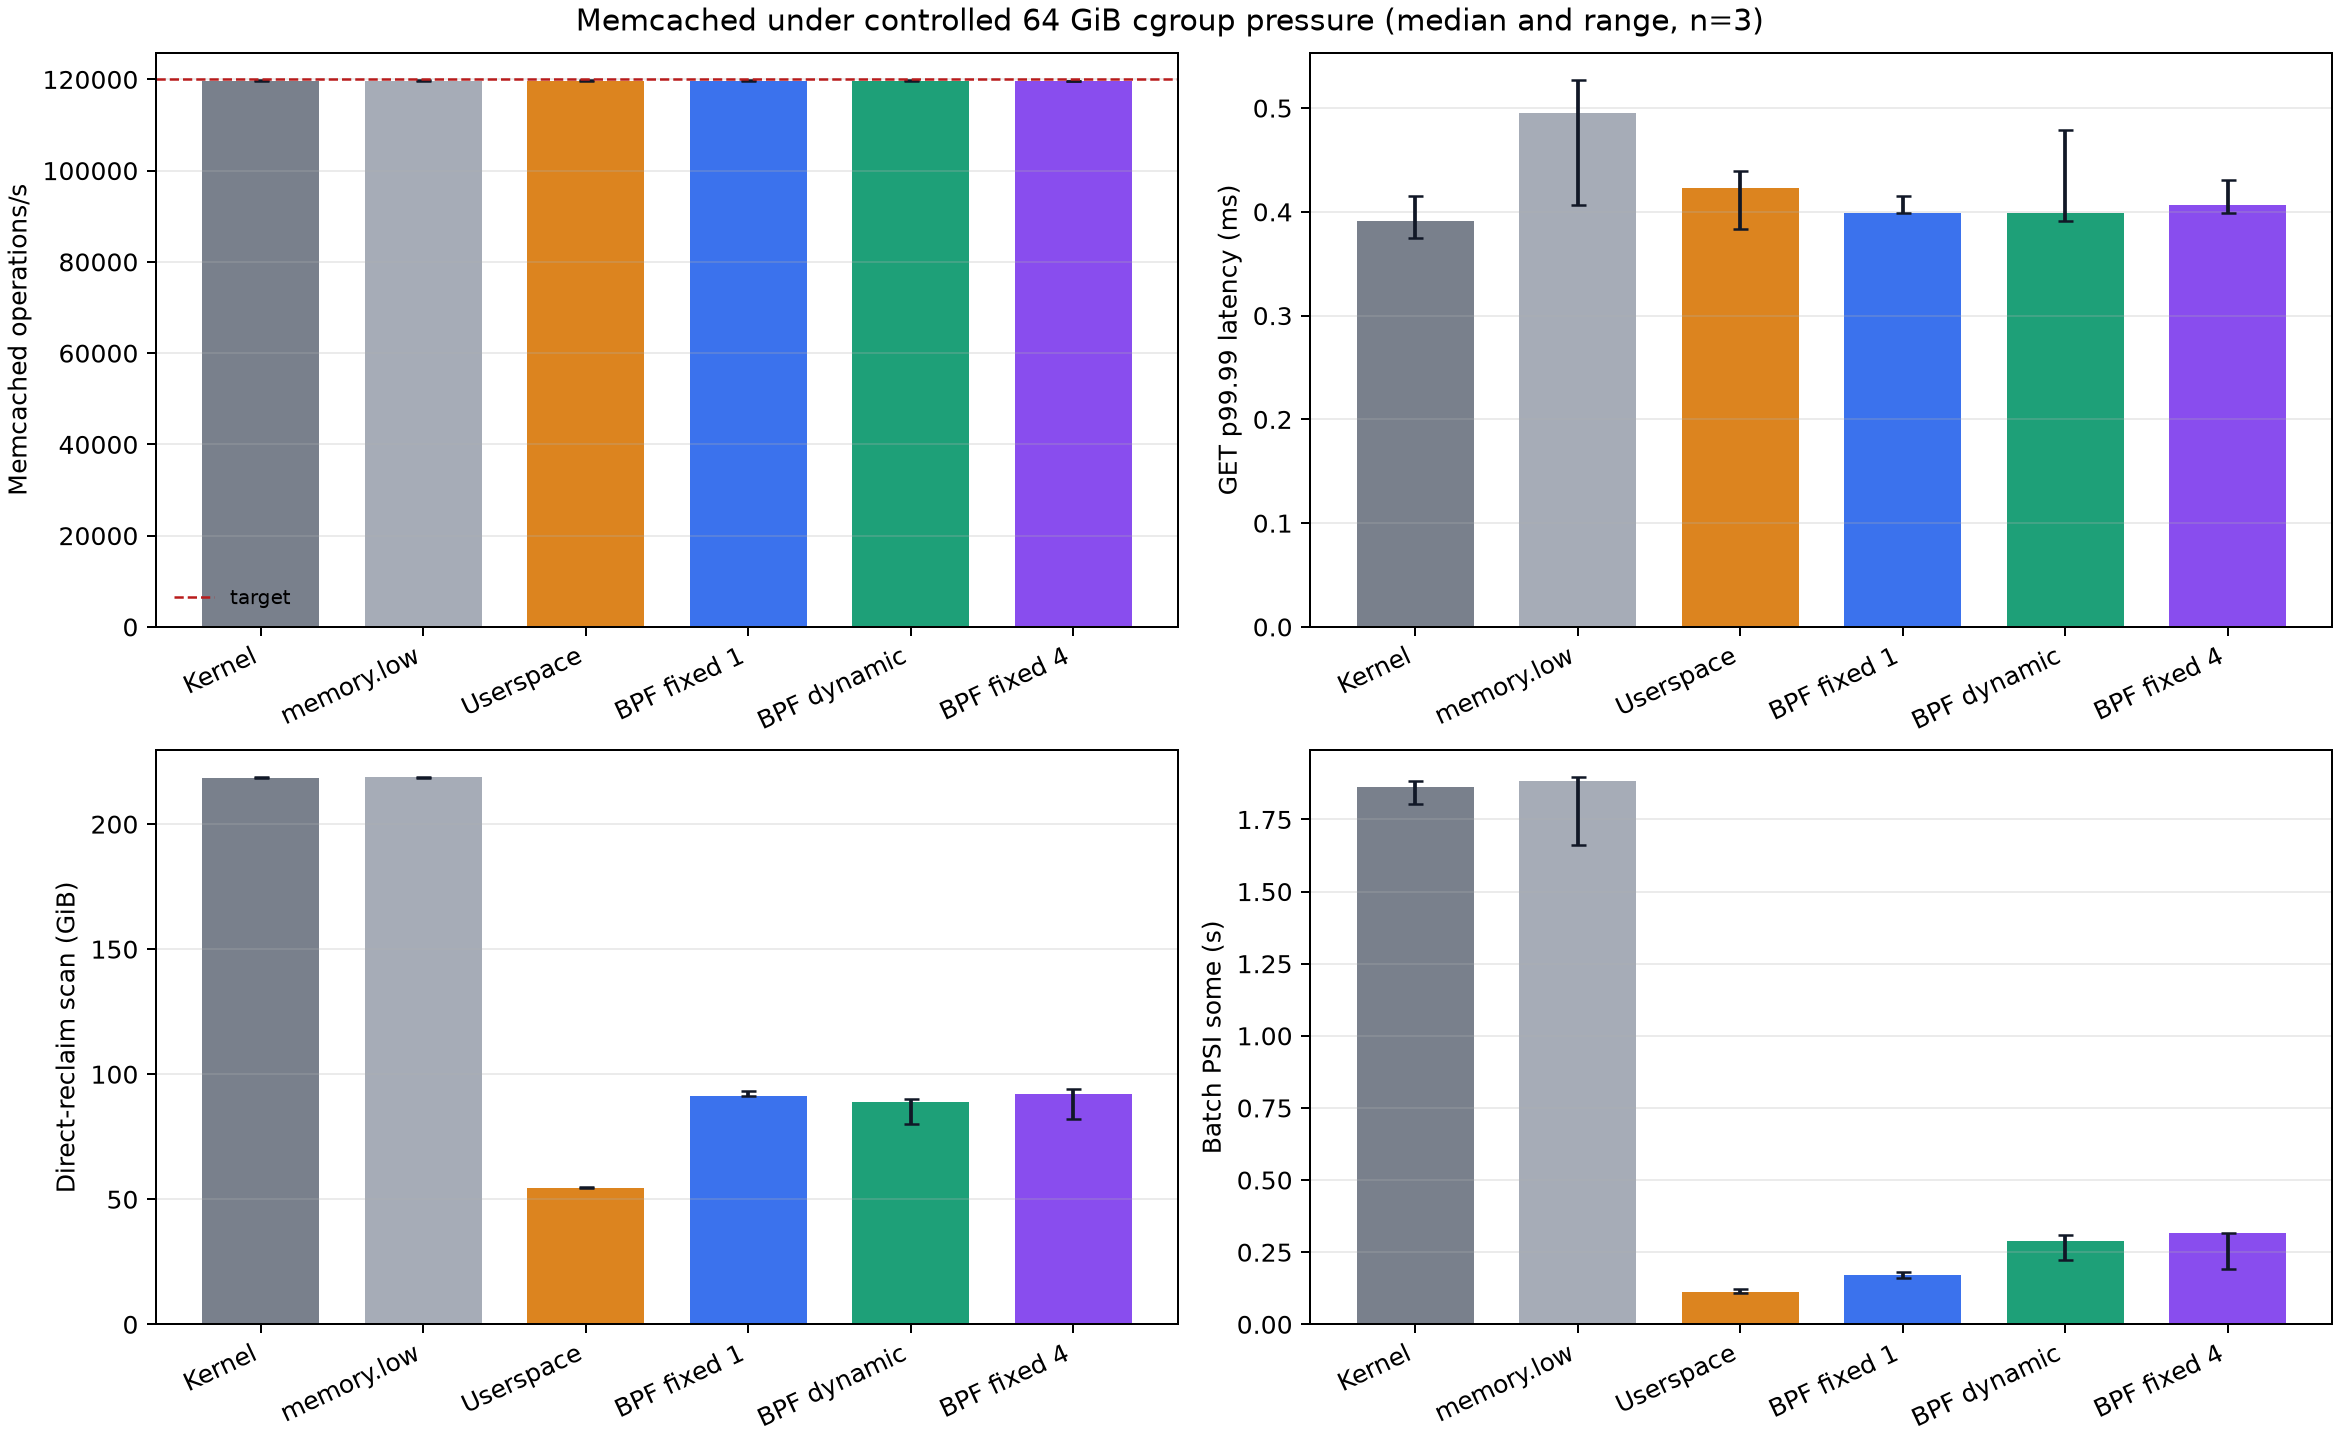

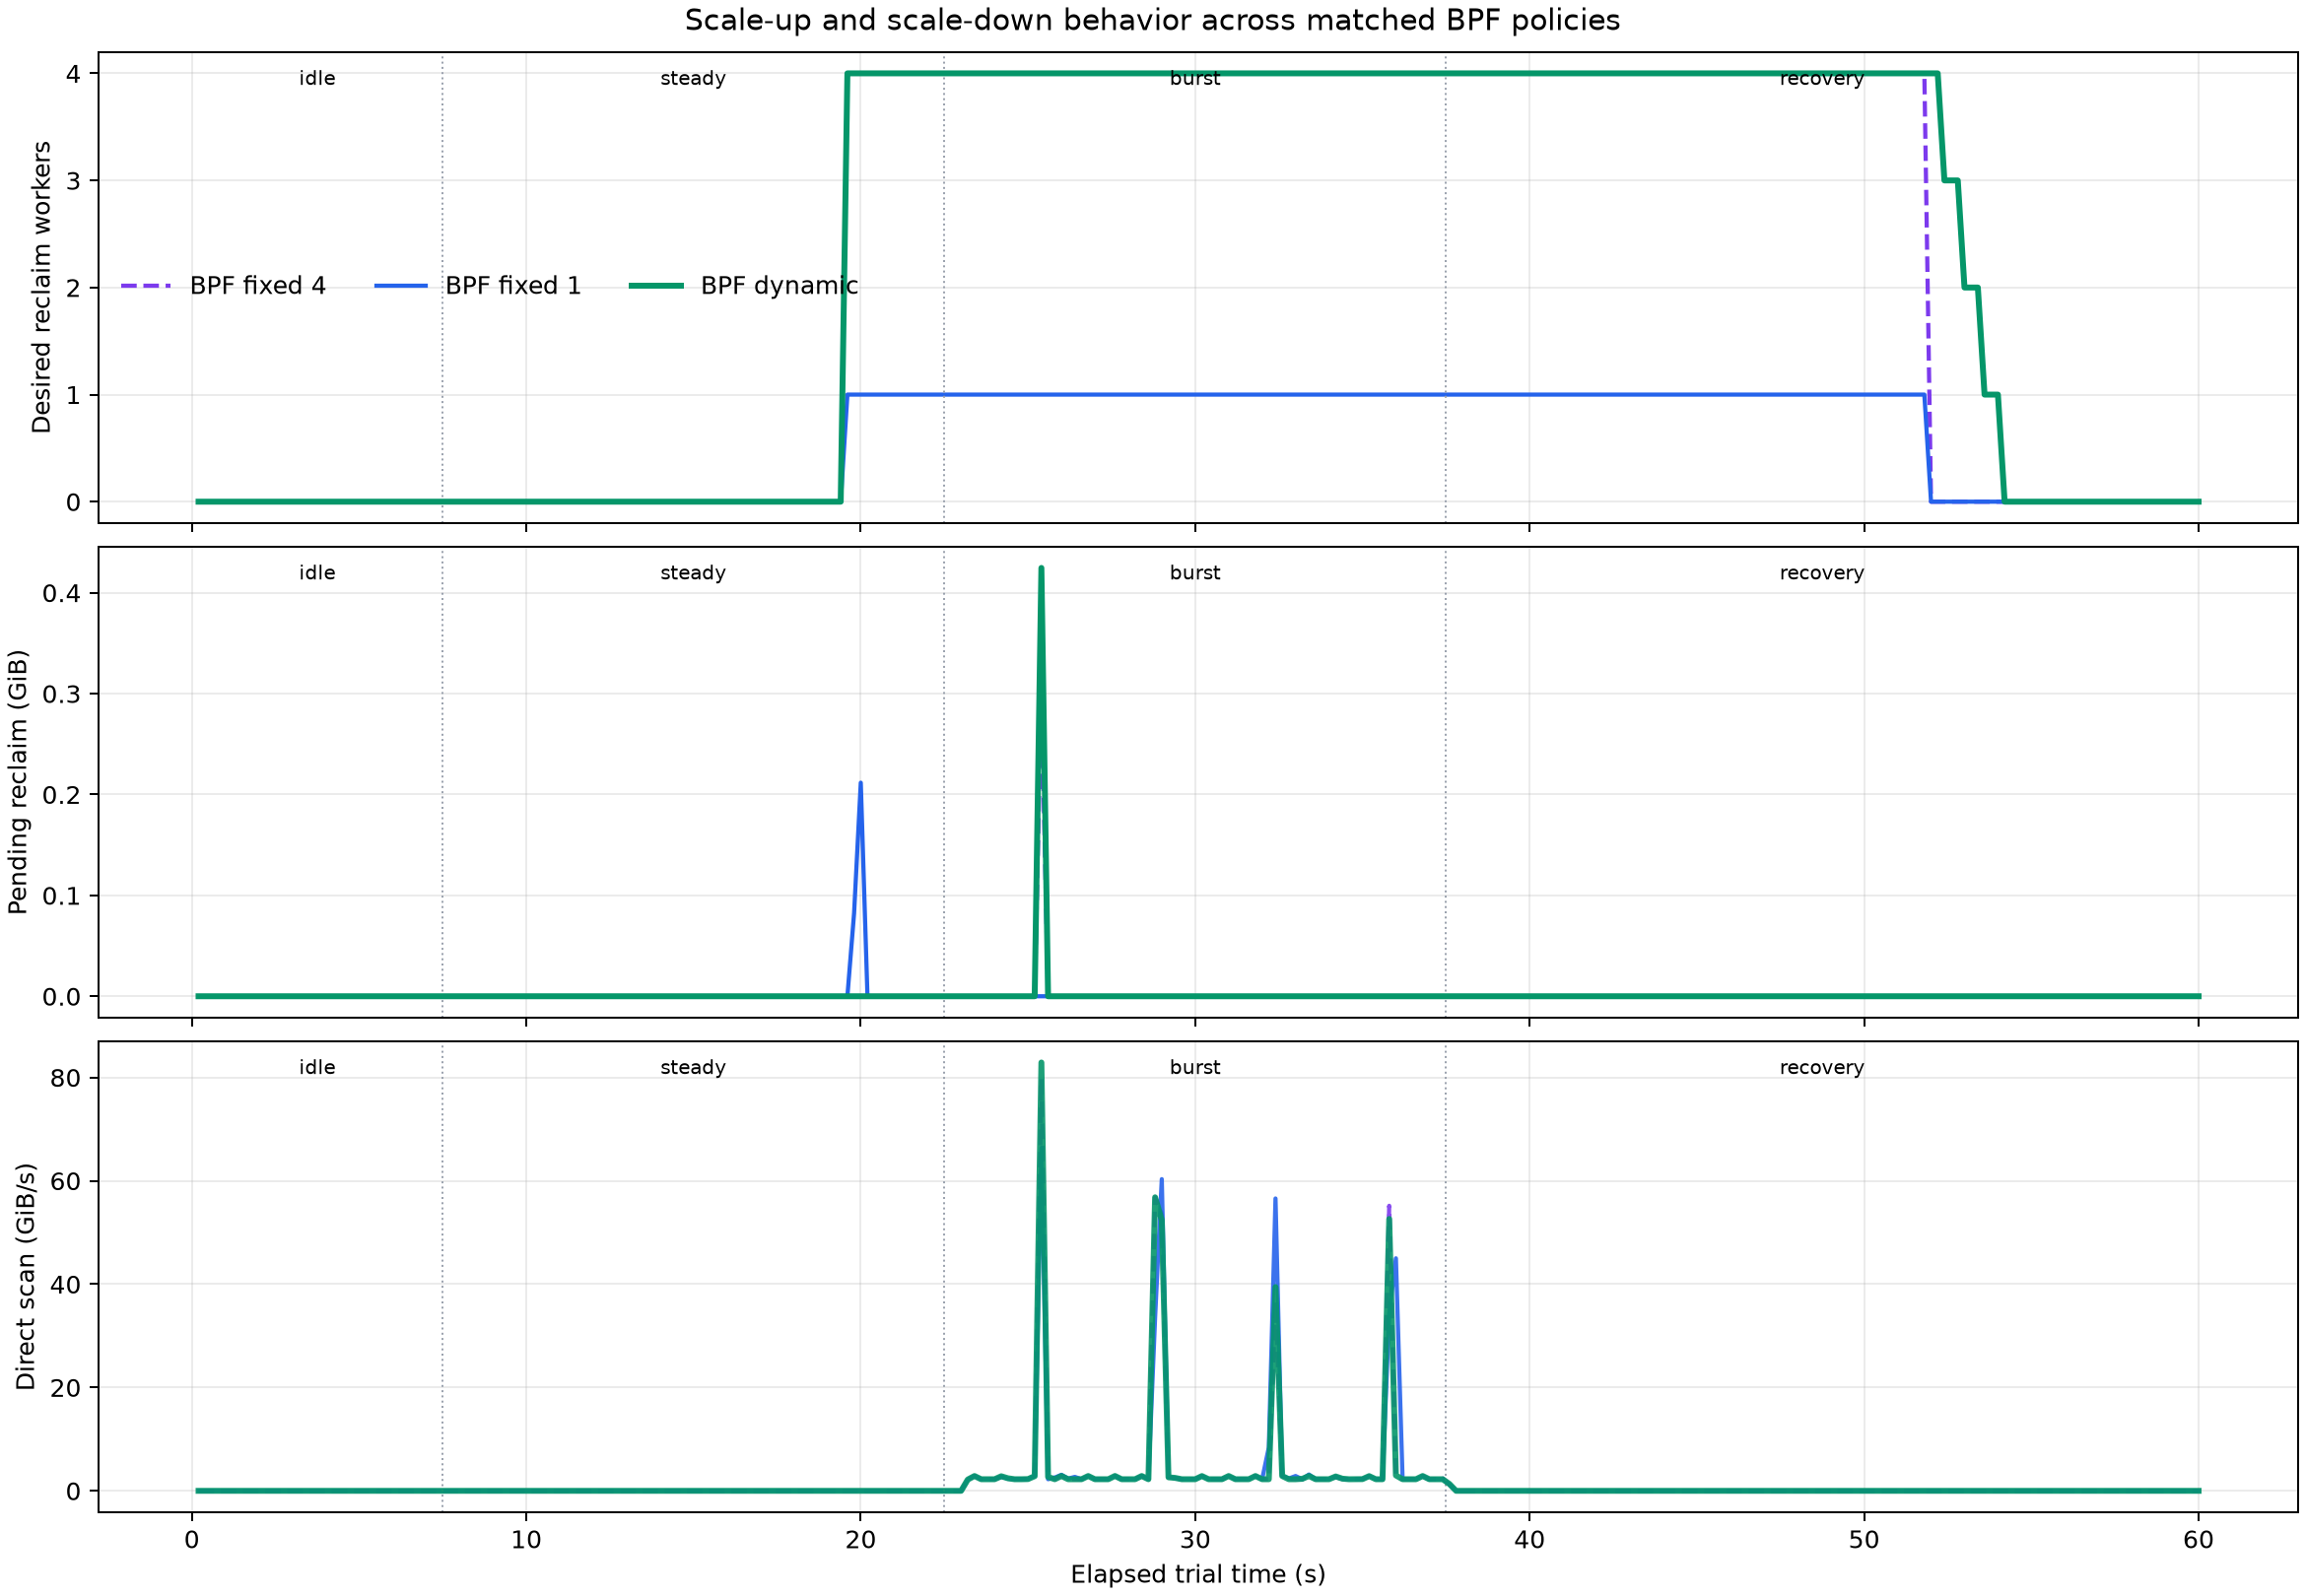

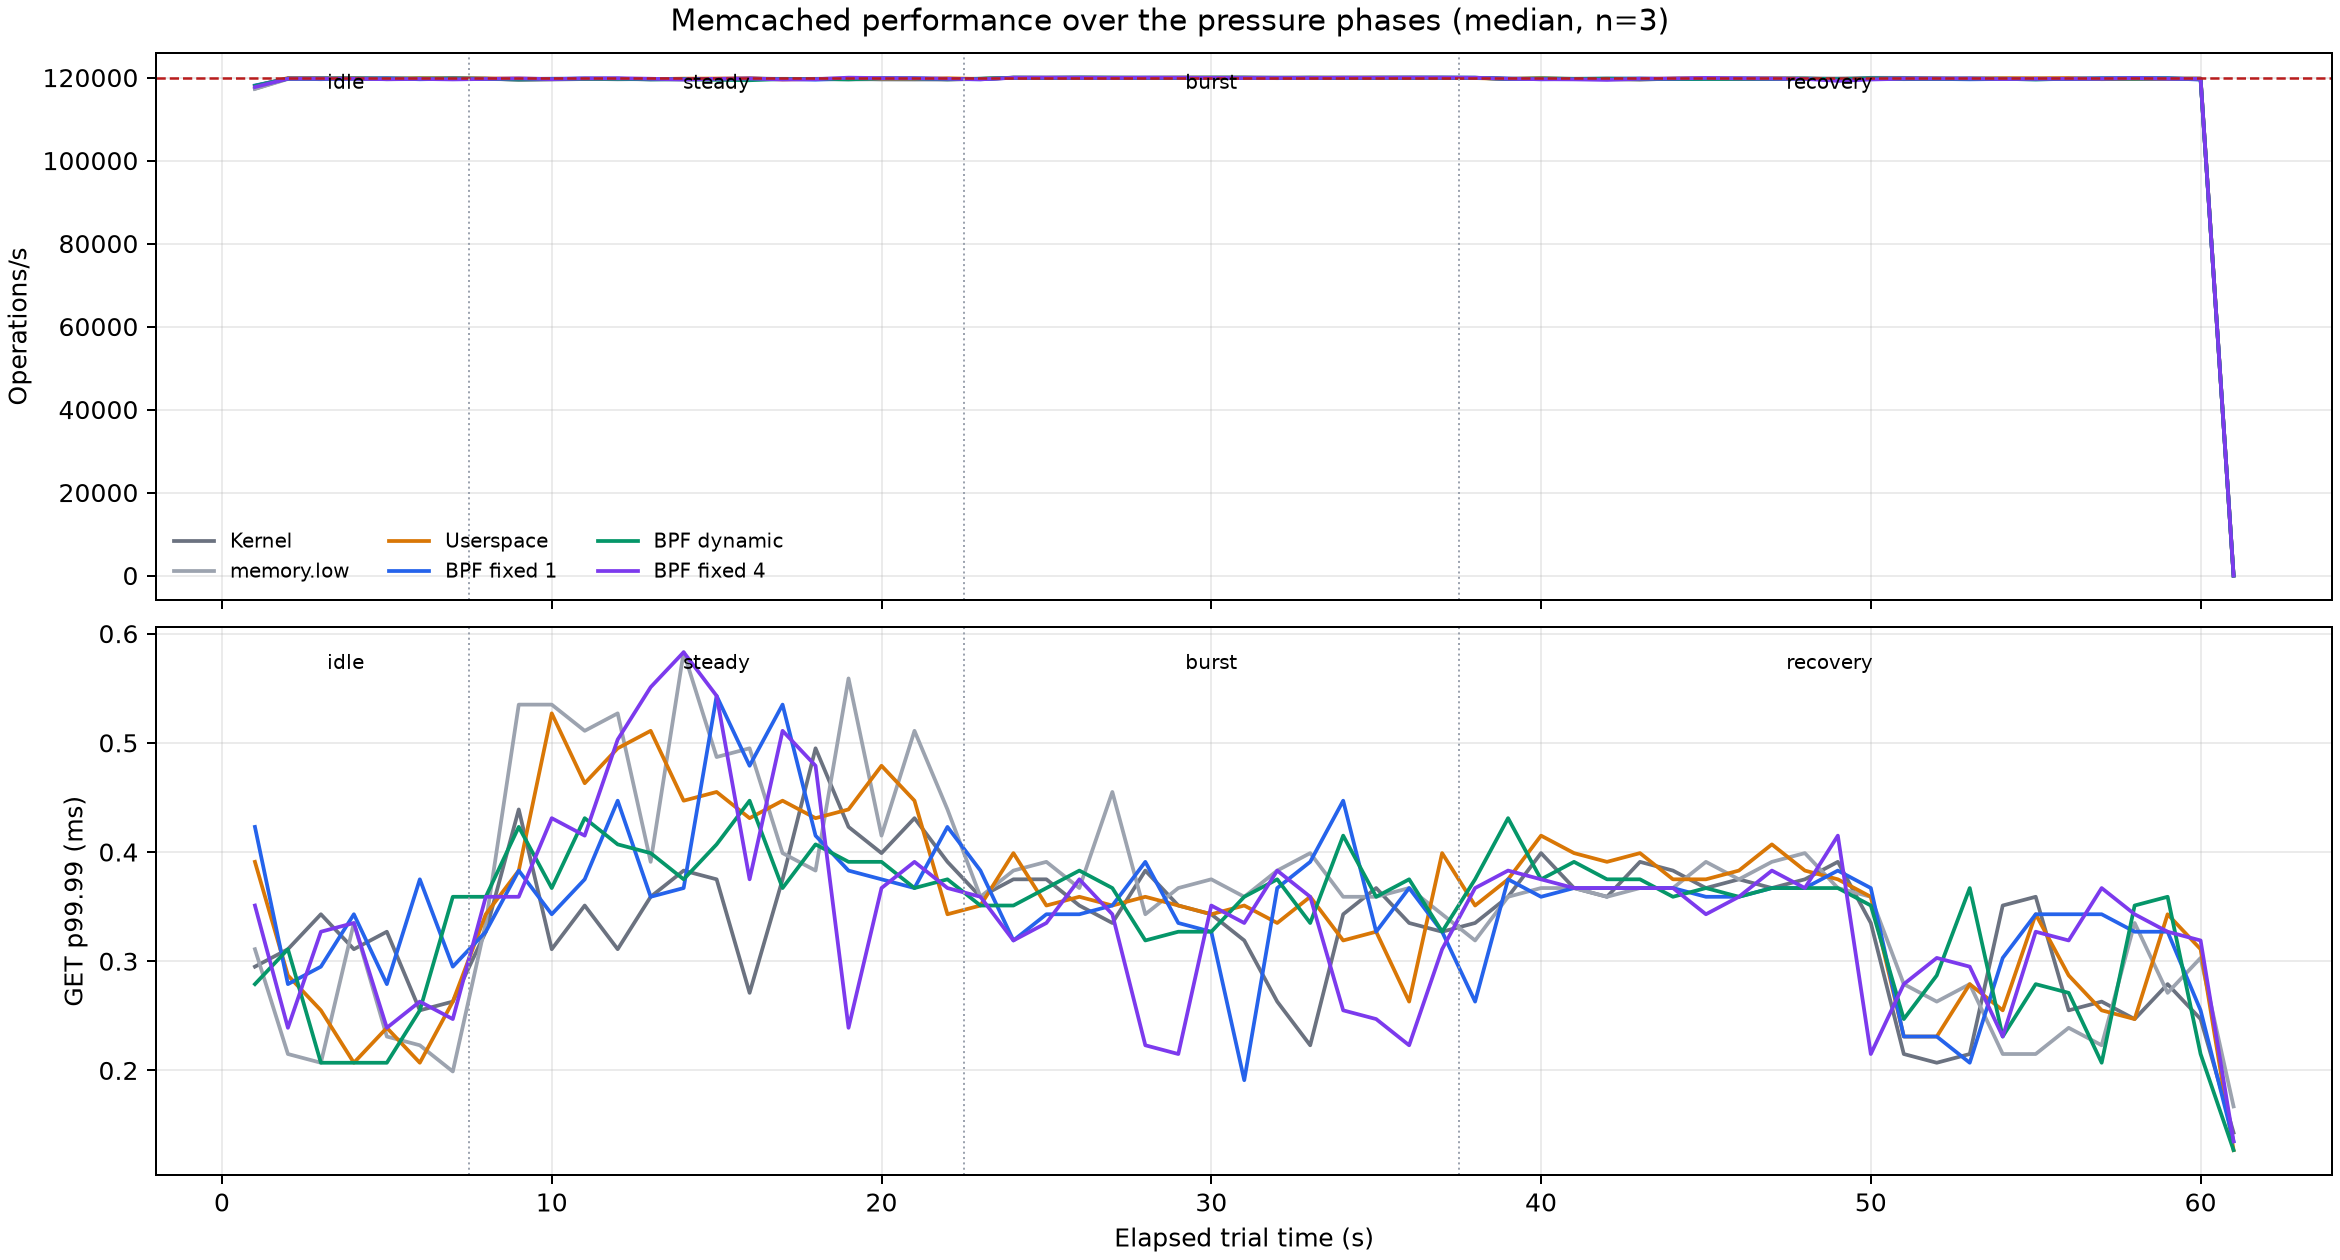

In [5]:
for figure in ['policy_comparison.png', 'controller_scaling.png', 'service_timeseries.png']:
    display(Image(filename=str(RESULTS / figure)))